![](../../../images/header.png)

# Mapping the Universe

<h6>Author : Hernan Rincon</h6>
<h6>Last Updated : October 11, 2025</h6>

The DESI Survey is making a giant, three-dimensional map of the universe. This map will allow scientists to study some of the biggest mysteries in physics, chief among them being the nature of dark energy. Most maps that you see in your day-to-day life are two-dimensional, so it may be hard to picture what a three dimensional map looks like in your head. This notebook will detail how DESI is creating its map of the universe, what this map looks like, and how you can create your own version of such a map with DESI data.

By the end of this notebook, you should be able to:
- Read maps of the night sky with right ascension and declination coordinates
- Understand the concept of a survey footprint and how DESI observes the night sky with overlapping survey tiles
- Create a three-dimensional map of DESI galaxies along with a corresponding two-dimensional cross section

## Preferred Backgrounds
While not necessary, having knowledge about the following topics will be helpful in completing this notebook on time:

- How Jupyter cells work
- How to depict data visually by using graphs

**Run the cell below to load the basic Python packages we need to run this notebook.**

In [1]:
import numpy as np
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
from desihigh import projections

## 1 - Map Projections

Before we discuss maps of the universe, let's first introduce maps of the Earth. Since our planet Earth is a sphere, we will often make maps that are **projections** of this sphere onto a flat surface, like the one seen below.

<img src="../../../images/Earth-Mollweide-projection.jpg" alt="" width="600"/>

<h6> Source : <a href="https://earthobservatory.nasa.gov/">NASA Earth Observatory</a></h6>

Maps that are projections will often distort the shapes of Earth's continents in order to represent a three-dimensional planet on a two-dimensional surface. That is the case for the map pictured above.

Maps of the night sky can also be projected onto a two-dimensional map. The below map is one such example. This map shows the band of the Milky Way galaxy, which you can see by eye in dark night skies far away from city lights.

<img src="../../../images/Milky_Way_infrared.jpg" alt="" width="600"/>

<h6> Source : <a href="https://www.ipac.caltech.edu/2mass/">Two Micron All Sky Survey</a></h6>

As is the case for Earth's continents, objects in the night sky may appear distorted by the projection of the map. To better understand how this distortion behaves, let's make our own map of the night sky. We will use data from the <a href="https://map.gsfc.nasa.gov/">WMAP collaboration</a> that tells us how hot or cold the electromagnetic radiation in different parts of the night sky is.

First, let's load in the WMAP temperature data.

In [1]:
import sys
sys.path.insert(1, '/global/homes/h/hrincon/code/desihigh/')


In [2]:
from desihigh import projections

In [3]:
import numpy as np
import healpy as hp

In [4]:
earth_map = np.fromfile('../../../data/earth_map_healpix.BIN', dtype=np.float32)


In [5]:
# load in temperature map data
sky_map = hp.read_map('../../../data/wmap_band_iqumap_r9_7yr_W_v4.fits')

Now let's create a map of the temperature of the night sky. The appearance of the map will depend on the rotation at which we view it. Run the below cell to create the map.


### 1.1 - Longitude and Latitude

<img src="../../../images/Earth-Mollweide-projection.jpg" alt="" width="600"/>

<h6> Source : <a href="https://earthobservatory.nasa.gov/">NASA Earth Observatory</a></h6>


To tell where we are located on our planet Earth, we can use **longitude (long.)** and **latitude (lat.)**. Longitude and latitude are angles and have units of degrees (°). To become more familiar with these units, let’s take a look at the below map. Our friend BaoBan the coyote (the DESI outreach ambassador) is hanging out in the center of the map.

<img src="../../../images/latlong/Earth-Mollweide-projection_0.jpg" alt="" width="600"/>

The blue line on this map is called the equator, and it passes through South America, Africa, and Asia (and BaoBan). When we are on the equator, we have a latitude of 0 degrees. When we are north of (above) the equator, we have a positive latitude value, with the largest possible latitude value being 90 degrees at the north pole. When we are south of (below) the equator, we have a negative latitude value, with the lowest possible latitude value being -90 degrees at the south pole.

The green line on the map is called the Prime Meridian, and it passes through Europe, Africa, and Antarctica (and BaoBan). When we are on the Prime Meridian, we have a longitude of 0 degrees. When we are east (right) of the Prime Meridian, we have a positive longitude with the largest possible latitude value being 180 degrees on the eastern edge of the map. When we are west (left) of the equator, we have a negative latitude value, with the lowest possible longitude value being -180 degrees at the western edge of the map.


The equator and the Prime Meridian cross each other in the center of the map. BaoBan is at this location, which is labeled 0 degrees longitude and 0 degrees latitude. Let’s now go with BaoBan on an adventure around the world. If BaoBan moves east (right) on the map, then his longitude value will increase from 0.

<img src="../../../images/latlong/Earth-Mollweide-projection_1.jpg" alt="" width="600"/>

Now BaoBan has a longitude of 34 degrees and a latitude of 0 degrees, and he is near Lake Victoria. This lake is one of the largest in the world and is bordered by several countries in Africa. If BaoBan next moves north (up) on the map, his latitude will increase from 0.

<img src="../../../images/latlong/Earth-Mollweide-projection_2.jpg" alt="" width="600"/>

BaoBan now has a longitude of 34 degrees and a latitude of 40 degrees, and he is in the country of Turkey. If he next moves to the east, his longitude value will increase, and he will pass through Asia and cross the Pacific Ocean. He will then wrap around the edge of the map and arrive in North America.

<img src="../../../images/latlong/Earth-Mollweide-projection_3.jpg" alt="" width="600"/>

Now BaoBan has a longitude of 286 degrees and a latitude of 40 degrees. He is in the United States. Now he is west (left) of the Prime Meridian, so it would be conventional to write his longitude as a negative value. However, we are going to use our own custom convention and keep his longitude as a positive number. Next, BaoBan is going to head south, so his latitude will decrease.

<img src="../../../images/latlong/Earth-Mollweide-projection_4.jpg" alt="" width="600"/>

BaoBan is now south of the equator, so he has a negative latitude of -14 degrees. He is in the country of Peru. For the last stretch of his journey, he will move east, so his longitude will increase.

<img src="../../../images/latlong/Earth-Mollweide-projection_5.jpg" alt="" width="600"/>

Now BaoBan is back at the Prime Meridian, and his longitude has increased to 360 degrees. Since there are only 360 degrees in a circle, an angle of 360 degrees is equivalent to an angle of 0 degrees. So we can also say that Baoban has a longitude of 0 degrees.

TODO: add some images of locaitons ot break up teh trvel, add a plotting excersize where ou can specify lon lat

can you find a lat lon value in north America? Africa? Australia? Antartica?

In [8]:
import importlib
importlib.reload(projections)

<module 'desihigh.projections' from '/global/homes/h/hrincon/code/desihigh/desihigh/projections.py'>

show different projections (mollview, gnomic, etc) and discuss how they sacrifice accuracy of teh shapes of continents.

Latitude and longitude (lat. and long. for short) are coordinates that tell us where we are on the Earth. Latitude lines are horizontal lines on the Earth's surface that are are parallel to the equator. Longitude lines are vertical lines on the Earth's surface that start and end at the Earth's north and south poles.

<table>
  <tr>
    <td>
      <img src="../../../images/latitude.jpg" alt="" width="600"/>
    </td>
    <td>
      <img src="../../../images/longitude.jpg" alt="" width="600"/>
    </td>
  </tr>
</table>
<h6> Source : <a href="https://www.nasa.gov/learning-resources/nasas-picture-dictionary-l/">NASA's Picture Dictionary</a></h6>

Any point on the Earth's surface sits on a line of latitude and a line of longitude. For example, the below code will plot a map of the Earth with a star in its center. The star will sit on a pink line of latitude and a blue line of longitude. Run the below code to see the location of the star and its lines of latitude (lat.) and longitude (long.).

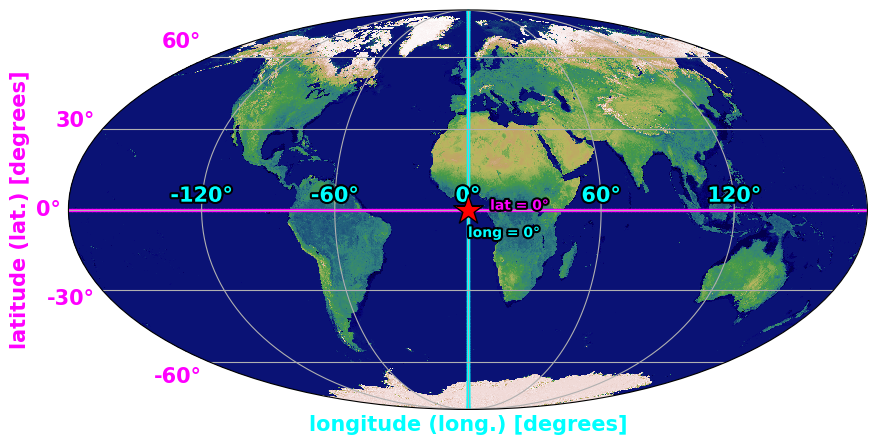

In [15]:
latitude = 0
longitude = 0

projections.plot_earth_map(earth_map, longitude, latitude)


The star is labeled with its coordinate of latitude (lat = 0 deg) and its coodinate of longitude (long = 0 deg). These coodinates are both in units of degrees, and their values are set by the `latitude` and `longitude` variables in the above code. 

 - Try changing the `latitude` variable from `0` to `30` and rerun the code. What changes about the location of the star and the pink latitude line? 

 - What happens if you set the `latitude` variable to `45`? What about `60`? What about `90`? Rerun the code and find out. 

 - What happens if you set the `latitude` variable equal a negative number? Try setting it to `-30`, `-60`, and `-90`, and take note of how the location of the star changes each time.

As you might have discovered, lines of latitude take on values between 90 and -90 and they tell us how far north or south we are.

 - Put the `latitude` variable back to `0`. Now try changng the `longitude` variable. What happens to the location of the star and the blue longitude line when you change the variable to `60`. What about `120`? What about `180`?

 -  What happens if you set the `longitude` variable equal to a negative number? Try setting it to `-30`, `-150`, and `-180`, and take note of how the location of the star changes each time.

As you might have discovered, lines of longitude take on values between -180 and 180 and they tell us how far west or east we are. **Can you find a latitude and longitude value that will place the star where you live on the Earth?**


DECISION: move everything about offsets to an appendix. We can use an intial offset for the radec map to match DESI and draw out own graticule labels (just like how we drew the star labels)

We are now going to fix `latitude = 0` and `longitude = 0` and experiment with how the curved surface of the globe is projected onto a flat map. To do this, we will introduce three new parameters: `longitude_offset`, `latitude_offset`, and `psi_offset`. Run the below code to create our next map.

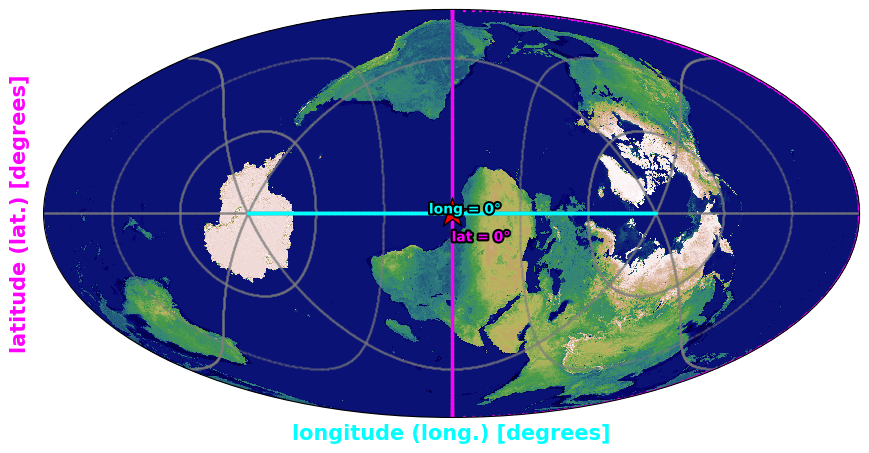

In [41]:
longitude_offset = 0
latitude_offset = 0
psi_offset = 90

projections.plot_transformed_earth_map(earth_map, 0, 0, longitude_offset, latitude_offset, psi_offset)

Let's look at the `longitude_offset` variable first. 

 - What happens to the location of the star, blue longitude line, and the continents togehter when you change the `longitude_offset` variable to `90`? Is Africa still in the middle of the map? 

 - Try changing the change the `longitude_offset` variable to several values between`180` and `-180`. How does the `longitude_offset` variable affect the way that the continents are projected onto the map? Do the shapes of the continents stay the same as you change the values? Hint: chose two locations at different latitudes (like Alaska and the continetal United States) and observe how far they appear from each other on your computer screen as you change the `longitude_offset` value.

Next, set `longitude_offset` back to `0`. We will now examine the `latitude_offset` variable.

 -  Try changing `latitude_offset` to different values between `90` and `-90`. What happens to the location of the star, the pink latitude line, and the continents together? Do the shapes of the continents stay the same as you change the `latitude_offset`? 

 - Remember, the disntaces and shapes of the real continents aren't actually chaning. It's just the projection of the 3D globe onto a 2D map that is different.

Set `latitude_offset` back to 0. We will now examine the `psi_offset` variable.

 - Try chaning the `psi_offset` vaiable to `5`, `15`, `30`, and `60`. What happens to the location of the star, the pink and blue lines, and the continents? Do the shapes of the continents stay the same as you change the values?

 - Try setting `psi_offset` to a few more values between `60` and `180`. Then try a few negative values between `0` and `-180`. Can you guess how the map will change based on the behavior you saw when you changed `psi_offset` between `5` and `60`?

Here us is a version of the code where you can change all the values we've introduced so far. Try experimenting with differnet values and see what happens.

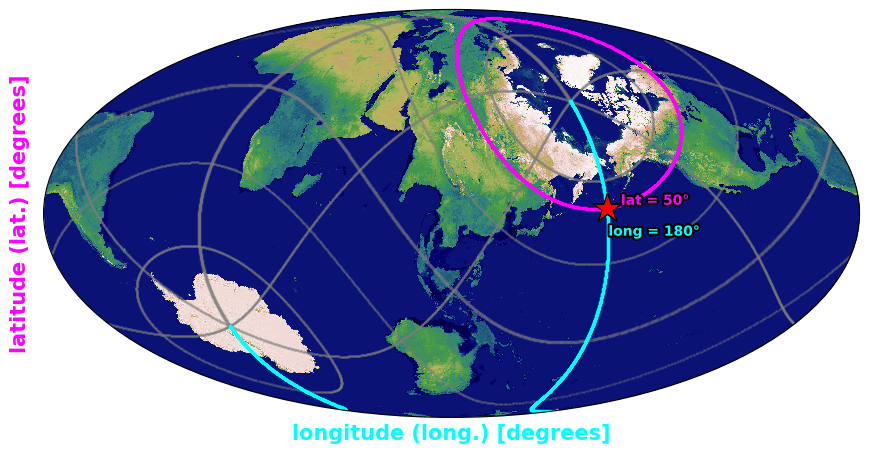

In [43]:
longitude = 180
latitude = 50

longitude_offset = 100
latitude_offset = 20
psi_offset = 45

projections.plot_transformed_earth_map(earth_map, longitude, latitude, longitude_offset, latitude_offset, psi_offset)

Trye out differnt RA values between 0 and 360. What happens when you cross 180 (going from 175 to 185)
Try out different declination values

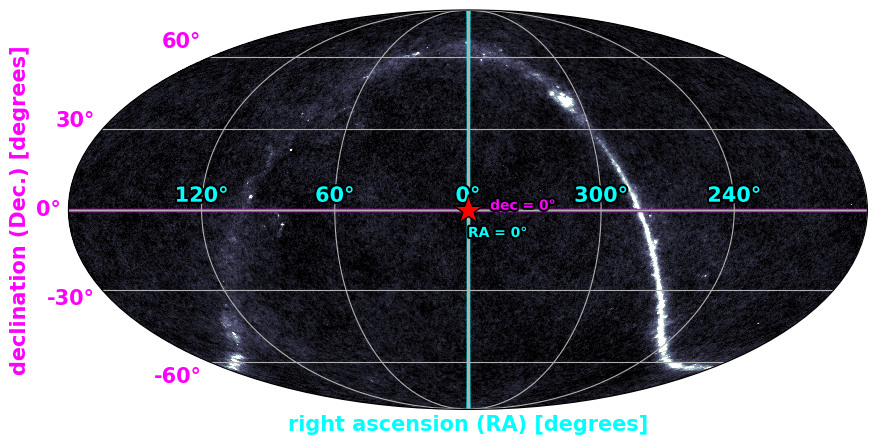

In [45]:
right_ascension = 0
declination = 0
projections.plot_sky_map(sky_map, right_ascension, declination)

match this with the DESI footprint projection by inputting teh corect offset (hin try a positive right_ascension_offset value)

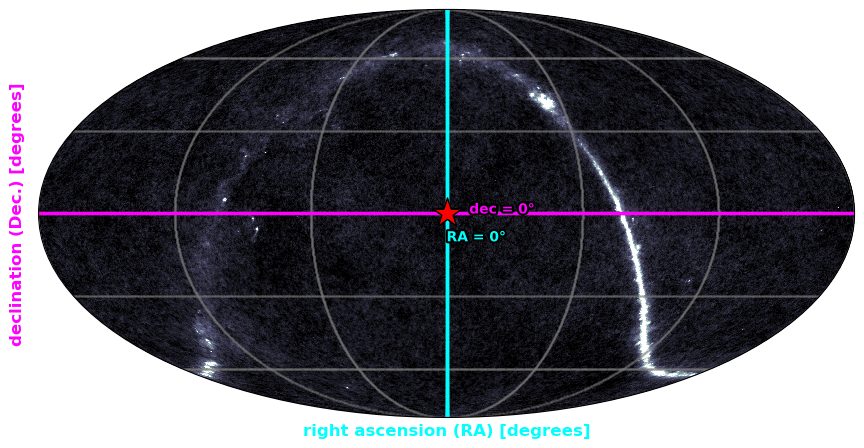

In [46]:
right_ascension = 0
declination = 0

right_ascension_offset = 0
declination_offset = 0
psi_offset = 0


projections.plot_transformed_sky_map(sky_map, right_ascension, declination, right_ascension_offset, declination_offset, psi_offset)

<img src="../../../images/dr1-bright-progress.png" alt="" width="600"/>

<h6> Source : <a href="https://arxiv.org/abs/2503.14745">First Public Data Release of the DESI Survey</a></h6>


clip from planetarium show showing transition to 3D sky

Compare your plot with the DESI footprint map we saw before. **Did DESI plan to observe in both the North Galactic Cap footprint and the South Galactic Cap footprint on 2021-09-22?**

<img src="../../../images/dr1-bright-progress.png" alt="" width="600"/>

<h6> Source : <a href="https://arxiv.org/abs/2503.14745">First Public Data Release of the DESI Survey</a></h6>

The green circles in the above map are individual DESI tiles. As the DESI survey carries on, multiple overlapping tiles pile up to cover the entire DESI footprint. You can see this overlapping coverage staring to take effect in the dark green regions.


## Conclusion

In this notebook, we have introduced DESI's map of the universe along with the map projections and coordinate systems that we can use to depict DESI data. We have additionally described how a night of DESI observing works, using overlapping survey tiles to make progress toward the survey's completion. 

The way that galaxies cluster together in DESI's map allows us to test theoretical models of cosmology. In the next notebook, we will introduce various scientific analyses that we can perform with DESI.

![](../../../images/footer.png)

<details>
  <summary><h6>Code solutions, do not open if not allowed</h6></summary>
  
**Exercise 1 : Projecting the Milky Way**
```python
# Try changing the value of map_rotation_angle to various 
# values between 0 and 360 degrees and observe how the 
# apparence of the map changes

map_rotation_angle = 0 # in units of degrees

hp.mollview(
    sky_map,
    rot = (0, 0, map_rotation_angle),
    title="Temperature Map of the Night Sky",
    unit="excess temperature (millikelvin)",
    min=-1,
    max=2,
    cmap = mpl.colormaps['bone']
)
```
An angle of 0 degrees, 90 degrees, 180 degrees, or 270 degrees causes the Milky Way to appear flat.




  </details>